/home/swanith/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


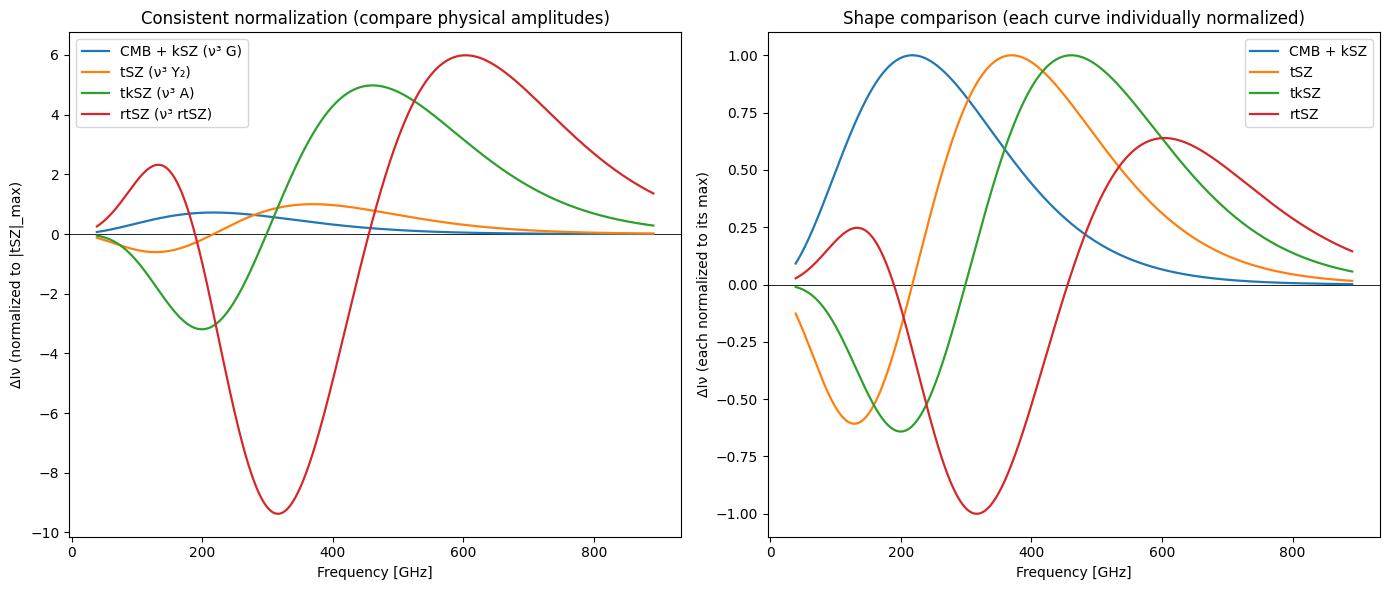

In [1]:
# Reproducible code to compute & plot SZ spectral responses (tSZ, kSZ, tkSZ, rtSZ)
# Saves figure to /mnt/data/sz_spectral_responses.png and writes the script to /mnt/data/sz_fig1.py
# This code uses an analytic expression for G and numerical derivatives for higher-order Y terms,
# multiplies by nu^3 to get intensity-like ΔIν, and provides both "common normalization" and
# "individual normalization" panels like in the previous notebook output.
#
# Run this cell to regenerate the figure. After execution, you'll find:
# - /mnt/data/sz_spectral_responses.png  (the plotted figure)
# - /mnt/data/sz_fig1.py                 (the script containing this code)
#
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# --- Physical constants and frequencies ---
T_cmb = 2.725  # K
h = 6.62607015e-34  # Planck constant [J s]
kB = 1.380649e-23   # Boltzmann constant [J/K]
c = 299792458.0     # speed of light [m/s]

# Frequency grid (Hz)
nu = np.linspace(30e9, 900e9, 2000)  # 30 GHz to 900 GHz (fine grid)
x = h * nu / (kB * T_cmb)

# --- Planck phase-space and spectral operators ---
def fbar(x):
    """Bose-Einstein occupation number 1/(e^x - 1)."""
    return 1.0 / (np.exp(x) - 1.0)

# Analytic G (the D operator applied to fbar): G = D fbar = -x df/dx
# where df/dx = - e^x / (e^x - 1)^2, so G = x * e^x / (e^x - 1)^2
G = x * np.exp(x) / (np.exp(x) - 1.0)**2

def D_operator_array(g, x):
    """Apply D = - x d/dx operator numerically to array g(x)."""
    dgdx = np.gradient(g, x)
    return - x * dgdx

# Compute Y(2) = (D^2 - 3D) fbar = D(G) - 3 G
D_G = D_operator_array(G, x)
Y2 = D_G - 3.0 * G

# Compute higher order Ys via D operator
Y3 = D_operator_array(Y2, x)
Y4 = D_operator_array(Y3, x)

# --- Spectral response functions from the paper ---
# tSZ response in phase-space is Y(2) (we use ν^3 * Y2 for intensity-like plotting)
# tkSZ A(ν) = (2/5) G - Y(2) + (7/5) Y(3)
A = (2.0/5.0) * G - Y2 + (7.0/5.0) * Y3
# rtSZ truncated expansion used in paper: -(3/10)Y2 - (21/10)Y3 + (7/10)Y4
rtSZ = -(3.0/10.0) * Y2 - (21.0/10.0) * Y3 + (7.0/10.0) * Y4

# Convert to intensity-like ΔIν (drop constant factor 2 h / c^2 which is common)
I_k = nu**3 * G        # CMB + kSZ term ∝ ν^3 G (kSZ effectively ∝ G but often plotted as ν^3 G)
I_t = nu**3 * Y2       # tSZ ∝ ν^3 Y(2)
I_tk = nu**3 * A       # tkSZ ∝ ν^3 A
I_rt = nu**3 * rtSZ    # rtSZ ∝ ν^3 * (rtSZ expression)

# Trim edges to avoid derivative boundary artifacts for plotting
trim = 20
nu_trim = nu[trim:-trim]
I_k_trim = I_k[trim:-trim]
I_t_trim = I_t[trim:-trim]
I_tk_trim = I_tk[trim:-trim]
I_rt_trim = I_rt[trim:-trim]

# Common normalization (use |tSZ|max to show physical amplitude differences)
common_norm = np.max(np.abs(I_t_trim))

# Plotting: left = common normalization, right = individual normalization
plt.figure(figsize=(14,6))

# Left panel: common normalization
plt.subplot(1,2,1)
plt.axhline(0, color='k', lw=0.6)
plt.plot(nu_trim/1e9, I_k_trim/common_norm, label='CMB + kSZ (ν³ G)', lw=1.6)
plt.plot(nu_trim/1e9, I_t_trim/common_norm, label='tSZ (ν³ Y₂)', lw=1.6)
plt.plot(nu_trim/1e9, I_tk_trim/common_norm, label='tkSZ (ν³ A)', lw=1.6)
plt.plot(nu_trim/1e9, I_rt_trim/common_norm, label='rtSZ (ν³ rtSZ)', lw=1.6)
plt.xlabel('Frequency [GHz]')
plt.ylabel('ΔIν (normalized to |tSZ|_max)')
plt.title('Consistent normalization (compare physical amplitudes)')
plt.legend()
#plt.grid(True)

# Right panel: each normalized separately (shape comparison)
plt.subplot(1,2,2)
plt.axhline(0, color='k', lw=0.6)
plt.plot(nu_trim/1e9, I_k_trim/np.max(np.abs(I_k_trim)), label='CMB + kSZ', lw=1.6)
plt.plot(nu_trim/1e9, I_t_trim/np.max(np.abs(I_t_trim)), label='tSZ', lw=1.6)
plt.plot(nu_trim/1e9, I_tk_trim/np.max(np.abs(I_tk_trim)), label='tkSZ', lw=1.6)
plt.plot(nu_trim/1e9, I_rt_trim/np.max(np.abs(I_rt_trim)), label='rtSZ', lw=1.6)
plt.xlabel('Frequency [GHz]')
plt.ylabel('ΔIν (each normalized to its max)')
plt.title('Shape comparison (each curve individually normalized)')
plt.legend()
#plt.grid(True)

plt.tight_layout()

plt.savefig("spectral_responses_sz")



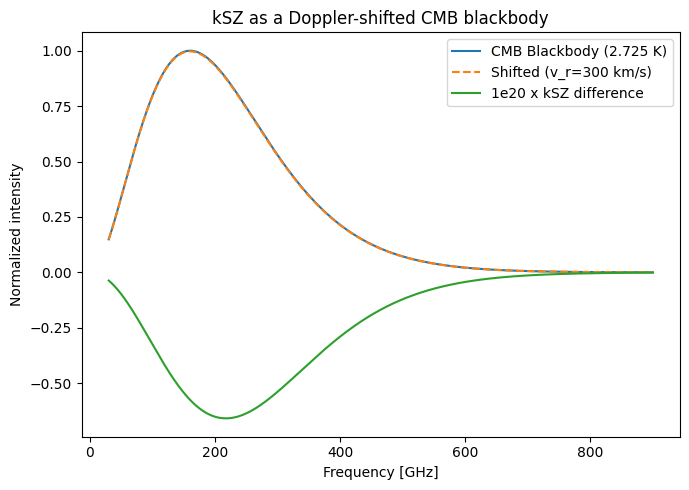

In [21]:
# --- kSZ vs CMB blackbody comparison ---

# Blackbody spectrum at T_CMB
B_nu = (2*h*nu**3/c**2) / (np.exp(x) - 1.0)

# Doppler-shifted CMB (kSZ)
v_r = 300e3  # m/s, example peculiar velocity (300 km/s)
T_shift = T_cmb * (1 - v_r/c)
x_shift = h*nu/(kB*T_shift)
B_shift = (2*h*nu**3/c**2) / (np.exp(x_shift) - 1.0)

# Difference spectrum (kSZ)
DeltaI_kSZ = B_shift - B_nu  # or ≈ (dB/dT)*DeltaT

plt.figure(figsize=(7,5))
plt.plot(nu/1e9, B_nu/np.max(B_nu), label='CMB Blackbody (2.725 K)')
plt.plot(nu/1e9, B_shift/np.max(B_nu), label='Shifted (v_r=300 km/s)', ls='--')
plt.plot(nu/1e9, 0.5*1e20*(DeltaI_kSZ), label='1e20 x kSZ difference')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Normalized intensity')
plt.legend()
plt.title('kSZ as a Doppler-shifted CMB blackbody')
plt.tight_layout()
plt.savefig("kSZ_SED.pdf")
plt.show()


/home/swanith/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


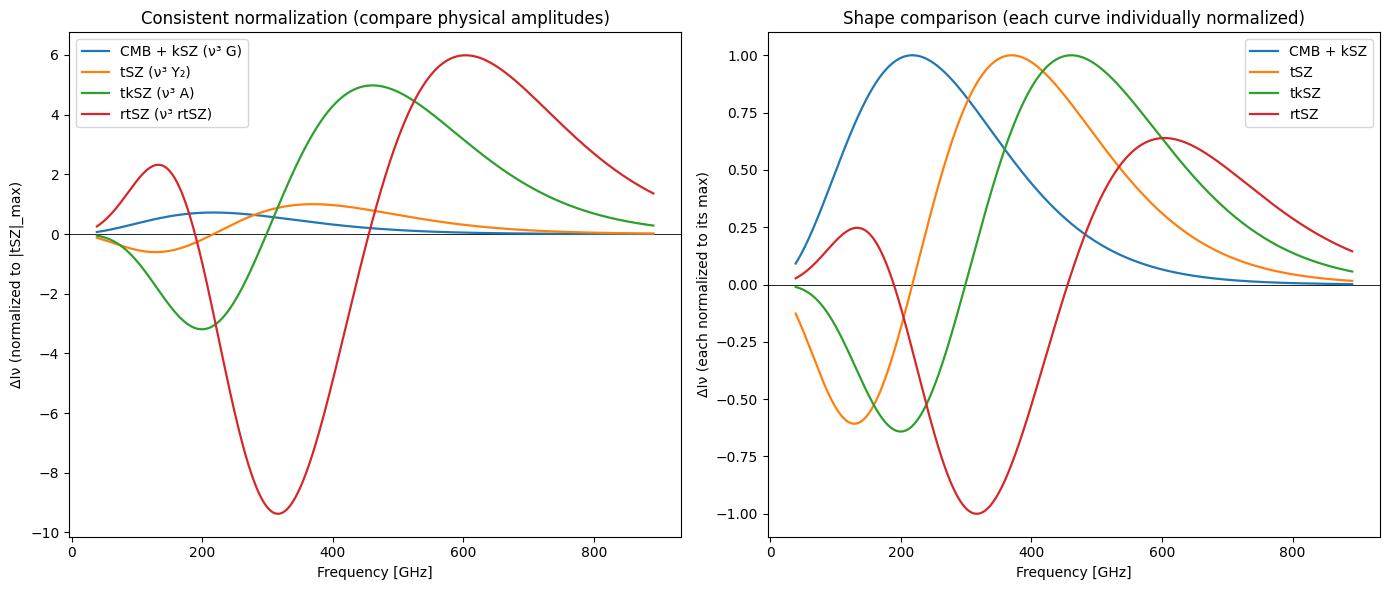

In [1]:
# Reproducible code to compute & plot SZ spectral responses (tSZ, kSZ, tkSZ, rtSZ)
# Saves figure to /mnt/data/sz_spectral_responses.png and writes the script to /mnt/data/sz_fig1.py
# This code uses an analytic expression for G and numerical derivatives for higher-order Y terms,
# multiplies by nu^3 to get intensity-like ΔIν, and provides both "common normalization" and
# "individual normalization" panels like in the previous notebook output.
#
# Run this cell to regenerate the figure. After execution, you'll find:
# - /mnt/data/sz_spectral_responses.png  (the plotted figure)
# - /mnt/data/sz_fig1.py                 (the script containing this code)
#
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# --- Physical constants and frequencies ---
T_cmb = 2.725  # K
h = 6.62607015e-34  # Planck constant [J s]
kB = 1.380649e-23   # Boltzmann constant [J/K]
c = 299792458.0     # speed of light [m/s]

# Frequency grid (Hz)
nu = np.linspace(30e9, 900e9, 2000)  # 30 GHz to 900 GHz (fine grid)
x = h * nu / (kB * T_cmb)

# --- Planck phase-space and spectral operators ---
def fbar(x):
    """Bose-Einstein occupation number 1/(e^x - 1)."""
    return 1.0 / (np.exp(x) - 1.0)

# Analytic G (the D operator applied to fbar): G = D fbar = -x df/dx
# where df/dx = - e^x / (e^x - 1)^2, so G = x * e^x / (e^x - 1)^2
G = x * np.exp(x) / (np.exp(x) - 1.0)**2

def D_operator_array(g, x):
    """Apply D = - x d/dx operator numerically to array g(x)."""
    dgdx = np.gradient(g, x)
    return - x * dgdx

# Compute Y(2) = (D^2 - 3D) fbar = D(G) - 3 G
D_G = D_operator_array(G, x)
Y2 = D_G - 3.0 * G

# Compute higher order Ys via D operator
Y3 = D_operator_array(Y2, x)
Y4 = D_operator_array(Y3, x)

# --- Spectral response functions from the paper ---
# tSZ response in phase-space is Y(2) (we use ν^3 * Y2 for intensity-like plotting)
# tkSZ A(ν) = (2/5) G - Y(2) + (7/5) Y(3)
A = (2.0/5.0) * G - Y2 + (7.0/5.0) * Y3
# rtSZ truncated expansion used in paper: -(3/10)Y2 - (21/10)Y3 + (7/10)Y4
rtSZ = -(3.0/10.0) * Y2 - (21.0/10.0) * Y3 + (7.0/10.0) * Y4

# Convert to intensity-like ΔIν (drop constant factor 2 h / c^2 which is common)
I_k = nu**3 * G        # CMB + kSZ term ∝ ν^3 G (kSZ effectively ∝ G but often plotted as ν^3 G)
I_t = nu**3 * Y2       # tSZ ∝ ν^3 Y(2)
I_tk = nu**3 * A       # tkSZ ∝ ν^3 A
I_rt = nu**3 * rtSZ    # rtSZ ∝ ν^3 * (rtSZ expression)

# Trim edges to avoid derivative boundary artifacts for plotting
trim = 20
nu_trim = nu[trim:-trim]
I_k_trim = I_k[trim:-trim]
I_t_trim = I_t[trim:-trim]
I_tk_trim = I_tk[trim:-trim]
I_rt_trim = I_rt[trim:-trim]

# Common normalization (use |tSZ|max to show physical amplitude differences)
common_norm = np.max(np.abs(I_t_trim))

# Plotting: left = common normalization, right = individual normalization
plt.figure(figsize=(14,6))

# Left panel: common normalization
plt.subplot(1,2,1)
plt.axhline(0, color='k', lw=0.6)
plt.plot(nu_trim/1e9, I_k_trim/common_norm, label='CMB + kSZ (ν³ G)', lw=1.6)
plt.plot(nu_trim/1e9, I_t_trim/common_norm, label='tSZ (ν³ Y₂)', lw=1.6)
plt.plot(nu_trim/1e9, I_tk_trim/common_norm, label='tkSZ (ν³ A)', lw=1.6)
plt.plot(nu_trim/1e9, I_rt_trim/common_norm, label='rtSZ (ν³ rtSZ)', lw=1.6)
plt.xlabel('Frequency [GHz]')
plt.ylabel('ΔIν (normalized to |tSZ|_max)')
plt.title('Consistent normalization (compare physical amplitudes)')
plt.legend()
#plt.grid(True)

# Right panel: each normalized separately (shape comparison)
plt.subplot(1,2,2)
plt.axhline(0, color='k', lw=0.6)
plt.plot(nu_trim/1e9, I_k_trim/np.max(np.abs(I_k_trim)), label='CMB + kSZ', lw=1.6)
plt.plot(nu_trim/1e9, I_t_trim/np.max(np.abs(I_t_trim)), label='tSZ', lw=1.6)
plt.plot(nu_trim/1e9, I_tk_trim/np.max(np.abs(I_tk_trim)), label='tkSZ', lw=1.6)
plt.plot(nu_trim/1e9, I_rt_trim/np.max(np.abs(I_rt_trim)), label='rtSZ', lw=1.6)
plt.xlabel('Frequency [GHz]')
plt.ylabel('ΔIν (each normalized to its max)')
plt.title('Shape comparison (each curve individually normalized)')
plt.legend()
#plt.grid(True)

plt.tight_layout()

plt.savefig("spectral_responses_sz")



/home/swanith/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Saved: total_SZ_or_combo.pdf


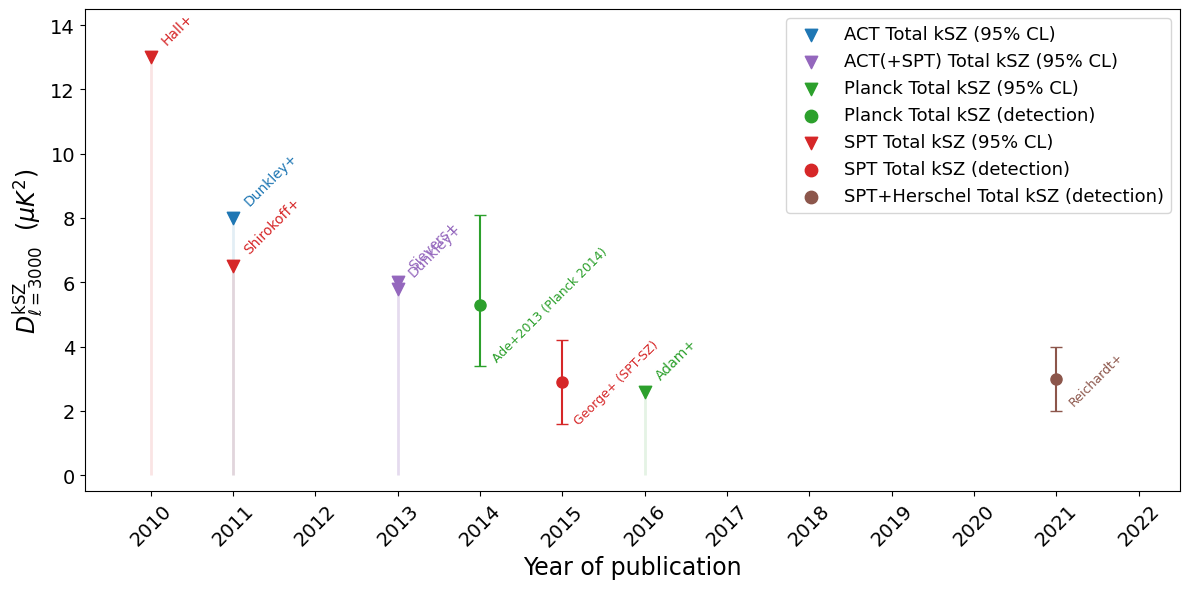

In [1]:
# CELL 1 – ONLY TRUE TOTAL kSZ + COMBO (NO PATCHY, NO MODEL UPPER LIMITS)
# --------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'grid.linestyle': '--', 'grid.alpha': 0.4, 'axes.facecolor': 'white'})

colors = {'SPT': '#d62728', 'ACT': '#1f77b4', 'Planck': '#2ca02c',
          'ACT(+SPT)': '#9467bd', 'SPT+Herschel': '#8c564b', 'Other': '#7f7f7f'}

type_marker = {'total': 'o', 'combo': 'o', 'patchy': 's', 'homogeneous': 'D', 'tsz': '^'}
type_label_friendly = {'total': 'Total kSZ', 'combo': 'tSZ + 0.46 kSZ', 'patchy': 'Patchy kSZ',
                       'homogeneous': 'Homogeneous kSZ', 'tsz': 'tSZ'}

# === WHITELIST: Only these labels go into Total/Combo plot ===
valid_total_combo_labels = {
    r'Lueker +',
    'Hall+ (95% CL)',
    'Dunkley+ (95% CL)',
    'Shirokoff+ (95% CL)',
    'Sievers+ (take)',
    'Dunkley+ (take: ACT+SPT)',
    'Ade+2013 (Planck 2014)',
    'George+ (SPT-SZ)',
    'Adam+ (Planck 2016 Battaglia model)',
    'Reichardt+'
}

ksz_data = [
    #(2010, 4.2, 1.5, 1.5, False, 'SPT', 'combo', r'Lueker +'),
    (2010, 13.0, None, None, True, 'SPT', 'total', 'Hall+ (95% CL)'),
    (2011, 8.0, None, None, True, 'ACT', 'total', 'Dunkley+ (95% CL)'),
    (2011, 6.5, None, None, True, 'SPT', 'total', 'Shirokoff+ (95% CL)'),
    (2012, 2.8, None, None, True, 'SPT', 'total', 'Reichardt+ (baseline Shaw/Sehgal)'),     # EXCLUDE
    (2012, 5.7, None, None, True, 'SPT', 'total', 'Reichardt+ (with patchy template & tSZ-CIB corr)'),  # EXCLUDE
    (2012, 4.9, None, None, True, 'SPT', 'patchy', 'Zahn+ (with tSZ-CIB corr)'),           # EXCLUDE
    (2013, 6.0, None, None, True, 'ACT(+SPT)', 'total', 'Sievers+ (take)'),
    (2013, 1.5, 0.5, 0.5, False, 'ACT', 'homogeneous', 'Sievers+ homogeneous'),             # EXCLUDE
    (2013, 5.8, None, None, True, 'ACT(+SPT)', 'total', 'Dunkley+ (take: ACT+SPT)'),
    (2014, 5.3, 1.9, 2.8, False, 'Planck', 'total', 'Ade+2013 (Planck 2014)'),
    (2015, 2.9, 1.3, 1.3, False, 'SPT', 'total', 'George+ (SPT-SZ)'),
    (2015, 4.4, None, None, True, 'SPT', 'patchy', 'George+ patchy (95% CL)'),              # EXCLUDE
    (2016, 2.6, None, None, True, 'Planck', 'total', 'Adam+ (Planck 2016 Battaglia model)'),
    (2021, 3.0, 1.0, 1.0, False, 'SPT+Herschel', 'total', 'Reichardt+'),
    (2021, 2.5, None, None, True, 'SPT+Herschel', 'patchy', 'Reichardt+ patchy (bispectrum, 95% CL)'), # EXCLUDE
]

def plot_entry(ax, entry, legend_handles):
    year, val, err_minus, err_plus, is_upper, exp, ktype, lbl = entry
    color = colors.get(exp, colors['Other'])
    marker = type_marker.get(ktype, 'o')

    if val is None:
        return legend_handles

    if is_upper:
        ax.scatter(year, val, marker='v', color=color, s=80, zorder=5)
        ax.vlines(year, 0, val, color=color, alpha=0.12, linewidth=2)
        short_lbl = lbl.split('(')[0].strip()
        ax.annotate(short_lbl, xy=(year + 0.1, val + 0.3), fontsize=10,
                    rotation=45, va='bottom', ha='left', color=color)
        hkey = (exp, ktype, 'upper')
        if hkey not in legend_handles:
            legend_handles[hkey] = ax.scatter([], [], marker='v', color=color, s=80,
                                              label=f'{exp} {type_label_friendly.get(ktype, ktype)} (95% CL)')
    else:
        if err_minus is None and err_plus is None:
            ax.scatter(year, val, marker=marker, color=color, s=80, zorder=6)
        else:
            lower = err_minus if err_minus is not None else err_plus
            upper = err_plus if err_plus is not None else err_minus
            yerr = np.array([[lower], [upper]])
            ax.errorbar(year, val, yerr=yerr, fmt=marker, color=color,
                        capsize=4, markersize=8, linewidth=1.5, zorder=6)
        ax.annotate(lbl, xy=(year + 0.12, val), fontsize=9,
                    rotation=45, va='center', ha='left', color=color)
        hkey = (exp, ktype, 'det')
        if hkey not in legend_handles:
            legend_handles[hkey] = ax.scatter([], [], marker=marker, color=color, s=80,
                                              label=f'{exp} {type_label_friendly.get(ktype, ktype)} (detection)')
    return legend_handles

def finalize_plot(ax, title, outfile):
    #ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('Year of publication', fontsize=17)
    ax.set_ylabel(r'$D^{\mathrm{kSZ}}_{\ell=3000}\ \ (\mu K^2)$', fontsize=17)
    ax.set_xlim(2009.2, 2022.5)
    ax.set_xticks(np.arange(2010, 2023, 1))
    plt.xticks(rotation=45)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_ylim(-0.5, 14.5)
    #ax.grid(True)

    handles, labels = [], []
    for h in legend_handles.values():
        handles.append(h)
        labels.append(h.get_label())

    if labels:
        combined = sorted(zip(labels, handles), key=lambda x: (x[0].split()[0], x[0]))
        labels, handles = zip(*combined)
        ax.legend(handles, labels, loc='upper right', fontsize=13, ncol=1)

    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    print(f'Saved: {outfile}')
    plt.savefig("total_SZ_or_combo.png", dpi=200)  # Save PNG version
    plt.show()
    plt.close()

# --- PLOT 1: ONLY TRUE TOTAL + COMBO ---
fig, ax = plt.subplots(figsize=(12, 6))
legend_handles = {}

for entry in ksz_data:
    lbl = entry[7]
    if lbl in valid_total_combo_labels:
        legend_handles = plot_entry(ax, entry, legend_handles)

finalize_plot(ax, 'Total kSZ + Combo Measurements', 'total_SZ_or_combo.pdf')


Saved: patchy_homogeneous_kSZ.pdf


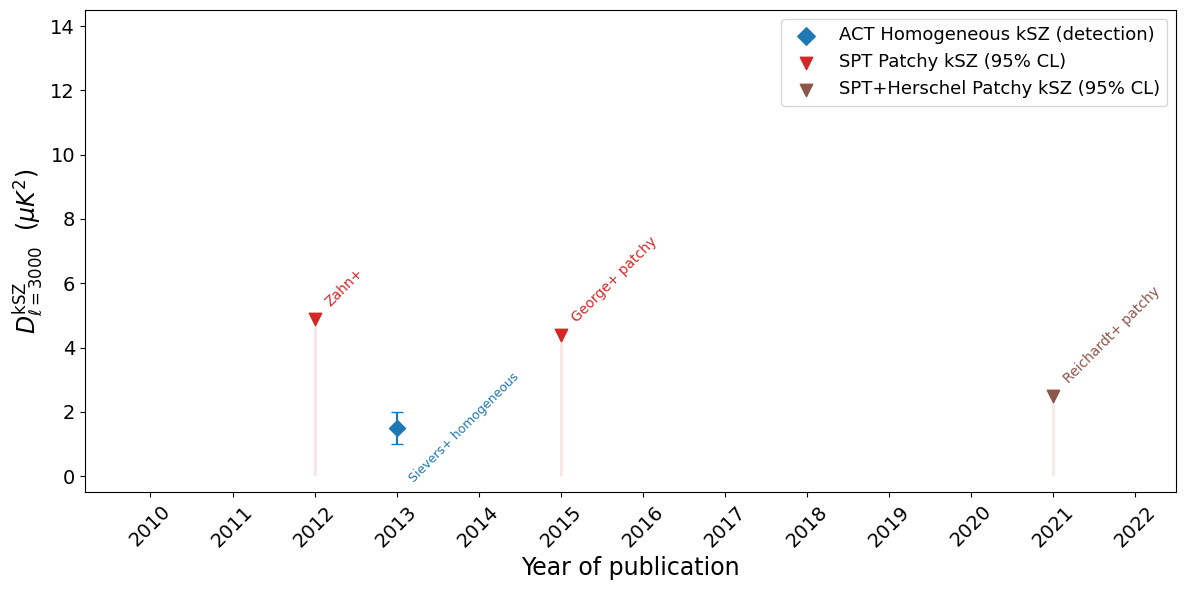

In [6]:
# CELL 2 – Patchy & Homogeneous kSZ
# --------------------------------------------------------------
# (Re-use same imports, functions, and data from Cell 1)

fig, ax = plt.subplots(figsize=(12, 6))
legend_handles = {}
for entry in ksz_data:
    if entry[6] in ('patchy', 'homogeneous'):
        legend_handles = plot_entry(ax, entry, legend_handles)
finalize_plot(ax, 'Patchy & Homogeneous kSZ', 'patchy_homogeneous_kSZ.pdf')

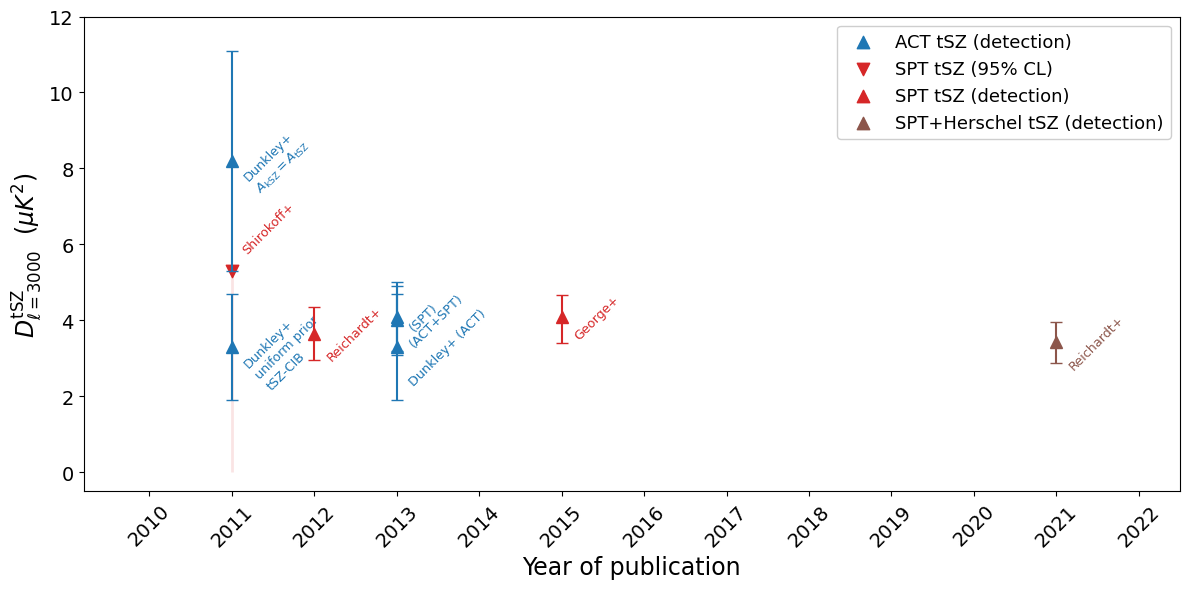

Saved: tSZ_measurements.pdf


In [3]:
# CELL 3 – tSZ Measurements (YOUR FINAL VERSION)
# --------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# Reuse colors from Cell 1
colors = {
    'ACT': '#1f77b4',           # blue
    'SPT': '#d62728',           # red
    'ACT(+SPT)': '#1f77b4',     # still blue – Dunkley is ACT lead
    'SPT+Herschel': '#8c564b'
}

type_marker = {'tsz': '^'}
type_label_friendly = {'tsz': 'tSZ'}

# --- tSZ Data with CLEAN, TWO-LINE LABELS ---
tsz_data = [
    # (year, val, err-, err+, is_upper, exp, type, label_lines)
    #(2010, 4.2, 1.5, 1.5, False, 'SPT', 'combo', r'Lueker +'),
    #DtSZ3000 + 0.5 DkSZ3000 = 4.5 ± 1.0 μK 
    (2011, 8.2, 2.9, 2.9, False, 'ACT', 'tsz',
     ['Dunkley+', r'$A_{\rm kSZ}=A_{\rm tSZ}$']),
    (2011, 3.3, 1.4, 1.4, False, 'ACT', 'tsz',
     ['Dunkley+', r'uniform prior', r'tSZ-CIB']),
    (2011, 5.3, None, None, True, 'SPT', 'tsz',
     ['Shirokoff+']),
    (2012, 3.65, 0.69, 0.69, False, 'SPT', 'tsz', ['Reichardt+']),
    (2013, 3.3, 1.4, 1.4, False, 'ACT', 'tsz', ['Dunkley+ (ACT)']),
    (2013, 4.1, 0.9, 0.9, False, 'ACT', 'tsz', ['(SPT)']),
    (2013, 4.0, 0.9, 0.9, False, 'ACT', 'tsz', ['(ACT+SPT)']),
    (2015, 4.08, 0.67, 0.58, False, 'SPT', 'tsz', ['George+']),
    (2021, 3.42, 0.54, 0.54, False, 'SPT+Herschel', 'tsz', ['Reichardt+']),
]

def plot_tsz_entry(ax, entry, legend_handles):
    year, val, err_minus, err_plus, is_upper, exp, ktype, label_lines = entry
    color = colors.get(exp, '#7f7f7f')
    marker = type_marker[ktype]

    if val is None:
        return legend_handles

    if is_upper:
        ax.scatter(year, val, marker='v', color=color, s=80, zorder=5)
        ax.vlines(year, 0, val, color=color, alpha=0.12, linewidth=2)
        # Two-line label
        label_text = '\n'.join(label_lines)
        ax.annotate(label_text, xy=(year + 0.1, val + 0.4),
                    fontsize=9.2, rotation=45, va='bottom', ha='left',
                    color=color, linespacing=1.2)
        hkey = (exp, 'upper')
        if hkey not in legend_handles:
            legend_handles[hkey] = ax.scatter([], [], marker='v', color=color, s=80,
                                              label=f'{exp} tSZ (95% CL)')
    else:
        if err_minus is None:
            ax.scatter(year, val, marker=marker, color=color, s=80, zorder=6)
        else:
            lower = err_minus
            upper = err_plus if err_plus is not None else err_minus
            yerr = np.array([[lower], [upper]])
            ax.errorbar(year, val, yerr=yerr, fmt=marker, color=color,
                        capsize=4, markersize=8, linewidth=1.5, zorder=6)
        # Two-line or single-line label
        label_text = label_lines[0] if len(label_lines) == 1 else '\n'.join(label_lines)
        ax.annotate(label_text, xy=(year + 0.12, val),
                    fontsize=9.2, rotation=45, va='center', ha='left',
                    color=color, linespacing=1.3)
        hkey = (exp, 'det')
        if hkey not in legend_handles:
            legend_handles[hkey] = ax.scatter([], [], marker=marker, color=color, s=80,
                                              label=f'{exp} tSZ (detection)')
    return legend_handles

def finalize_plot(ax, outfile):
    #ax.set_title('tSZ Power Spectrum Measurements', fontsize=14, pad=15)
    ax.set_xlabel('Year of publication', fontsize=17)
    ax.set_ylabel(r'$D^{\mathrm{tSZ}}_{\ell=3000}\ \ (\mu K^2)$', fontsize=17)
    ax.set_xlim(2009.2, 2022.5)
    ax.set_xticks(np.arange(2010, 2023, 1))
    plt.xticks(rotation=45)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_ylim(-0.5, 12.0)
    #ax.grid(True, alpha=0.3)

    handles, labels = [], []
    for h in legend_handles.values():
        handles.append(h)
        labels.append(h.get_label())

    # Sort by experiment name
    combined = sorted(zip(labels, handles), key=lambda x: x[0].split()[0])
    labels, handles = zip(*combined) if combined else ([], [])

    ax.legend(handles, labels, loc='upper right', fontsize=13, framealpha=0.95, ncol=1)

    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()
    print(f'Saved: {outfile}')
    plt.close()

# --- PLOT ---
fig, ax = plt.subplots(figsize=(12, 6))
legend_handles = {}

for entry in tsz_data:
    legend_handles = plot_tsz_entry(ax, entry, legend_handles)

finalize_plot(ax, 'tSZ_measurements.pdf')